# Aperture Filter Example

Here we learn how to evaluate different aperture filters using `pyweif`.

**[Run this NB in Google Colab](https://colab.research.google.com/github/matwey/pyweif/blob/master/docs/notebooks/aperture_filter.ipynb)**

## Install and import the required libraries

In [1]:
%pip install pyweif

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pyweif.af as af

## Evaluate and plot the aperture filters

Here we consider the following three aperture filters on a uniform grid $u \in [0, 5]$.

- The circular aperture filter:
$$
A(u) = \mathrm{jinc}_1^2(\pi u),
$$
where $\mathrm{jinc}_1(x) = \frac{2 J_1(x)}{x}$.
- The annular aperture (ring-shaped) filter:
$$
A(u) = \frac{\left(\mathrm{jinc}_1(\pi u) - \epsilon^2 \mathrm{jinc}_1(\pi \epsilon u)\right)^2}{(1 - \epsilon^2)^2}.
$$
- The covariance filter for two annular apertures:
$$
A(u) = \frac{\left(\mathrm{jinc}_1(\pi u) - \epsilon_1^2 \mathrm{jinc}_1(\pi \epsilon_1 u)\right)}{(1 - \epsilon_1^2)}\times \frac{\left(\mathrm{jinc}_1(\pi \alpha u) - \epsilon_2^2 \mathrm{jinc}_1(\pi \epsilon_2 \alpha u)\right)}{(1 - \epsilon_2^2)},
$$
where $\alpha = \frac{D_2}{D_1}$ denotes the aperture size ratio.

In [3]:
APERTURE_FILTERS = {
    "Circular": af.Circular(),
    r"Annular ($\epsilon=0.25$)": af.Annular(0.25),
    r"Cross annular ($D_2 / D_1=0.5905, \epsilon_1 = 0.6046, \epsilon_2 = 0$)": af.CrossAnnular(0.5905, 0.6046, 0.0),
}

In [4]:
U = np.linspace(0, 5, 1000)

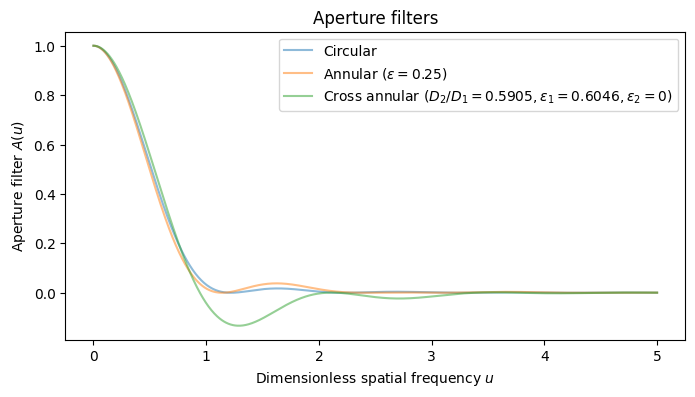

In [5]:
plt.figure(figsize=(8, 4))

for name, aperture_filter in APERTURE_FILTERS.items():
    plt.plot(U, aperture_filter(U), label=name, alpha=0.5)

plt.title("Aperture filters")
plt.xlabel("Dimensionless spatial frequency $u$")
plt.ylabel("Aperture filter $A(u)$")
plt.legend()

pass